# Bayesian Parameter Estimation & Regularization: Assumptions → Penalties → Bias/Variance/Stability

**Goal (for ML students):**
- Understand Bayesian parameter estimation in a standard supervised learning setting.
- See *exactly* how modeling assumptions (likelihood + prior) induce common regularization penalties.
- Connect Bayesian/MAP estimation to **bias–variance tradeoff** and **stability**.

**What you will do:**
1. Derive MAP estimation for common combinations (Gaussian/Laplace priors, Gaussian/Laplace likelihoods).
2. Empirically compare OLS vs Ridge vs Lasso vs Elastic Net on synthetic data.
3. Study bias/variance decomposition (empirical) and algorithmic stability (perturbation / leave-one-out style).

**Prereqs:** basic linear algebra, probability, linear regression, optimization.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error

np.random.seed(7)

plt.rcParams['figure.figsize'] = (9, 4.8)


## 1) Setup: supervised learning + Bayesian framing

We consider a dataset
$$
\mathcal{D} = \{(x_i, y_i)\}_{i=1}^n
$$
and a parametric model with parameters $\theta$.

### Likelihood
A **likelihood** $p(\mathcal{D}\mid \theta)$ encodes a noise model:
- Gaussian noise $\Rightarrow$ squared error loss
- Laplace noise $\Rightarrow$ absolute error loss

### Prior
A **prior** $p(\theta)$ encodes beliefs about plausible parameter values:
- Gaussian prior $\Rightarrow$ L2 penalty
- Laplace prior $\Rightarrow$ L1 penalty
- Mixtures / hierarchical priors $\Rightarrow$ richer penalties

### Posterior
$$
p(\theta \mid \mathcal{D}) \propto p(\mathcal{D} \mid \theta)\,p(\theta)
$$

Two important point estimates:
- **MAP:** $\theta_{MAP} = \arg\max_\theta p(\theta\mid\mathcal{D})$ (mode)
- **Posterior mean:** $\mathbb{E}[\theta\mid\mathcal{D}]$ (often better under squared error)

This notebook emphasizes MAP because it makes the regularization connection very explicit.


## 2) Core equivalence: MAP = empirical loss + regularizer

Start from
$$
\theta_{MAP} = \arg\max_\theta \log p(\mathcal{D} \mid \theta) + \log p(\theta).
$$
Equivalently
$$
\theta_{MAP} = \arg\min_\theta \big[-\log p(\mathcal{D} \mid \theta)\big] + \big[-\log p(\theta)\big].
$$
So:
- **negative log-likelihood** becomes the **data-fit term** (loss)
- **negative log-prior** becomes the **regularizer**

The constants don't matter for the argmin.


## 3) Example: Linear regression with Gaussian noise → MSE loss

Model:
$$
y = x^T w + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2)
$$
Likelihood:
$$
p(y\mid x,w) = \mathcal{N}(x^T w,\sigma^2).
$$
For i.i.d. data, the negative log-likelihood is (up to constants):
$$
-\log p(\mathcal{D}\mid w) \propto \frac{1}{2\sigma^2}\sum_{i=1}^n (y_i - x_i^T w)^2
$$
Thus **Gaussian noise** corresponds to minimizing **squared error**.


## 4) Assumptions → regularizers (common cases)

### 4.1 Gaussian prior on weights → Ridge (L2)
Assume
$$
w \sim \mathcal{N}(0, \tau^2 I).
$$
Then
$$
-\log p(w) \propto \frac{1}{2\tau^2}\|w\|_2^2.
$$
MAP becomes:
$$
\min_w \; \frac{1}{2\sigma^2}\|y - Xw\|_2^2 + \frac{1}{2\tau^2}\|w\|_2^2
$$
which is **Ridge regression**.

**Interpretation:** Gaussian prior expresses "weights should be small" but does not prefer exact zeros.

### 4.2 Laplace prior on weights → Lasso (L1)
Assume i.i.d. Laplace prior
$$
p(w_j) \propto \exp(-|w_j|/b).
$$
Then
$$
-\log p(w) \propto \sum_j |w_j| = \|w\|_1
$$
MAP becomes **Lasso**.

**Interpretation:** Laplace prior is peaked at 0 and has heavier tails than Gaussian, encouraging sparsity.

### 4.3 Gaussian + Laplace (as a prior product) → Elastic Net
Combine priors (or equivalently add penalties):
$$
\lambda_2 \|w\|_2^2 + \lambda_1 \|w\|_1
$$
giving **Elastic Net**.

### 4.4 Laplace noise → absolute loss (robust regression)
If
$$
\epsilon \sim \text{Laplace}(0, b)
$$
then
$$
-\log p(\mathcal{D}\mid w) \propto \sum_i |y_i - x_i^T w|
$$
so the **likelihood** choice changes the loss to L1 (robust to outliers).


## 5) Synthetic data generator

We'll create a controlled problem where:
- true $w^*$ is sparse
- features are correlated (to show Lasso vs Ridge behavior)
- we can vary sample size / noise and observe bias/variance/stability


In [2]:
@dataclass
class DataSpec:
    n: int = 60
    d: int = 40
    k_nonzero: int = 6
    noise_std: float = 2.0
    corr: float = 0.6

def make_correlated_X(n, d, corr=0.5):
    # AR(1)-like covariance: cov(i,j) = corr^{|i-j|}
    idx = np.arange(d)
    Sigma = corr ** np.abs(idx[:, None] - idx[None, :])
    L = np.linalg.cholesky(Sigma + 1e-10*np.eye(d))
    Z = np.random.randn(n, d)
    return Z @ L.T

def make_sparse_w(d, k_nonzero=5, scale=5.0):
    w = np.zeros(d)
    support = np.random.choice(d, size=k_nonzero, replace=False)
    w[support] = scale * np.random.choice([-1, 1], size=k_nonzero) * (0.5 + np.random.rand(k_nonzero))
    return w, support

def sample_dataset(spec: DataSpec):
    X = make_correlated_X(spec.n, spec.d, corr=spec.corr)
    w_star, support = make_sparse_w(spec.d, k_nonzero=spec.k_nonzero)
    y = X @ w_star + spec.noise_std * np.random.randn(spec.n)
    return X, y, w_star, support

spec = DataSpec()
X, y, w_star, support = sample_dataset(spec)
support, w_star[support]


(array([38, 22, 29, 20, 39,  9]),
 array([-3.9056581 , -3.27623232, -4.20118103, -3.8448283 ,  6.98741551,
         4.4761456 ]))

### Visualize true weights
A sparse $w^*$ makes the Laplace/L1 prior a plausible modeling choice.


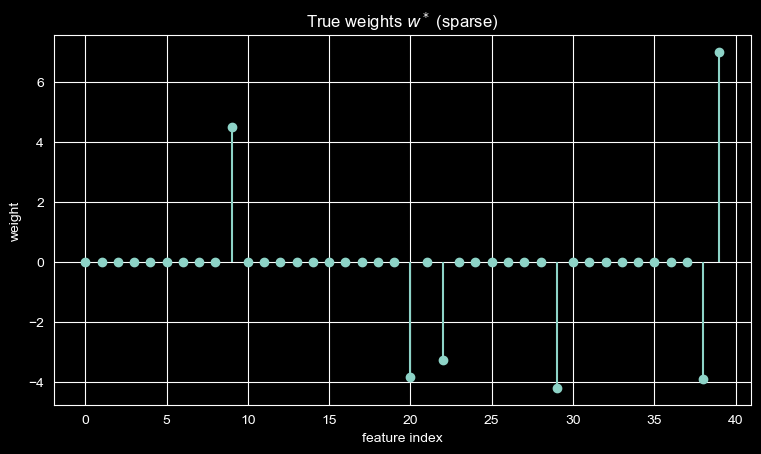

In [3]:
plt.stem(w_star, basefmt=" ")
plt.title("True weights $w^*$ (sparse)")
plt.xlabel("feature index")
plt.ylabel("weight")
plt.show()


## 6) Fit OLS / Ridge / Lasso / Elastic Net

Important practical detail: penalties depend on feature scaling.
We therefore standardize features before fitting Ridge/Lasso/ElasticNet.


In [4]:
def make_models(alpha_ridge=3.0, alpha_lasso=0.15, alpha_en=0.2, l1_ratio=0.5):
    # Use pipelines to standardize X (important for L1/L2 penalties)
    models = {
        "OLS": Pipeline([("scaler", StandardScaler()), ("m", LinearRegression())]),
        "Ridge": Pipeline([("scaler", StandardScaler()), ("m", Ridge(alpha=alpha_ridge))]),
        "Lasso": Pipeline([("scaler", StandardScaler()), ("m", Lasso(alpha=alpha_lasso, max_iter=10000))]),
        "ElasticNet": Pipeline([("scaler", StandardScaler()), ("m", ElasticNet(alpha=alpha_en, l1_ratio=l1_ratio, max_iter=10000))]),
    }
    return models

models = make_models()
for name, model in models.items():
    model.fit(X, y)
    yhat = model.predict(X)
    print(f"{name:10s} train MSE: {mean_squared_error(y, yhat):.3f}")


OLS        train MSE: 1.839
Ridge      train MSE: 3.138
Lasso      train MSE: 3.441
ElasticNet train MSE: 5.511


### Compare estimated coefficients
This reveals the geometric effect of priors:
- Ridge shrinks all coefficients smoothly
- Lasso drives many to exactly 0 (sparsity)
- ElasticNet mixes both behaviors


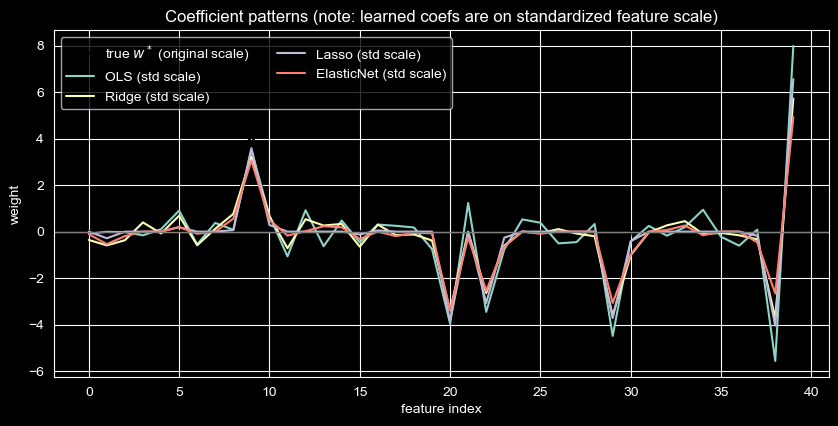

OLS        non-zeros (approx): 40/40
Ridge      non-zeros (approx): 40/40
Lasso      non-zeros (approx): 15/40
ElasticNet non-zeros (approx): 29/40


In [5]:
def get_coef_from_pipeline(pipe: Pipeline):
    # coefficients correspond to standardized features; still useful to compare shrinkage patterns
    return pipe.named_steps["m"].coef_.copy()

coefs = {name: get_coef_from_pipeline(model) for name, model in models.items()}

plt.figure(figsize=(10,4.5))
x = np.arange(spec.d)
plt.plot(x, w_star, "k-", lw=2, label="true $w^*$ (original scale)")
for name in ["OLS", "Ridge", "Lasso", "ElasticNet"]:
    plt.plot(x, coefs[name], lw=1.5, label=f"{name} (std scale)")
plt.axhline(0, color="gray", lw=1)
plt.title("Coefficient patterns (note: learned coefs are on standardized feature scale)")
plt.xlabel("feature index")
plt.ylabel("weight")
plt.legend(ncol=2)
plt.show()

for name in ["OLS", "Ridge", "Lasso", "ElasticNet"]:
    nnz = np.sum(np.abs(coefs[name]) > 1e-8)
    print(f"{name:10s} non-zeros (approx): {nnz}/{spec.d}")


## 7) Bias–Variance tradeoff (empirical)

For a fixed $x$ (or a distribution over $x$), classical decomposition is:
$$
\mathbb{E}[(\hat{f}(x) - y)^2] = \underbrace{(\mathbb{E}[\hat{f}(x)] - f(x))^2}_{\text{bias}^2} + \underbrace{\mathbb{V}[\hat{f}(x)]}_{\text{variance}} + \underbrace{\sigma^2}_{\text{irreducible noise}}
$$
We will estimate bias/variance by repeatedly sampling datasets and evaluating predictions on a fixed test set.

**Expectation:**
- OLS: low bias, high variance (especially with correlated features / small n)
- Ridge: higher bias, lower variance
- Lasso: can have more bias (if it zeros true small weights) but can reduce variance a lot


In [6]:
def bias_variance_experiment(spec: DataSpec, models, R=200, test_n=500):
    # Fix a test set and a single ground-truth w* for the whole experiment.
    X_test = make_correlated_X(test_n, spec.d, corr=spec.corr)
    w_star, support = make_sparse_w(spec.d, k_nonzero=spec.k_nonzero)
    f_test = X_test @ w_star  # noiseless target

    preds = {name: [] for name in models}

    for _ in range(R):
        X = make_correlated_X(spec.n, spec.d, corr=spec.corr)
        y = X @ w_star + spec.noise_std * np.random.randn(spec.n)

        for name, model in models.items():
            m = model
            m.fit(X, y)
            preds[name].append(m.predict(X_test))

    results = {}
    for name in models:
        P = np.stack(preds[name], axis=0)  # (R, test_n)
        mean_pred = P.mean(axis=0)
        bias2 = np.mean((mean_pred - f_test)**2)
        var = np.mean(P.var(axis=0))
        # expected test MSE includes noise too; approximate E[(pred - y)^2] with added sigma^2
        mse = bias2 + var + spec.noise_std**2
        results[name] = {"bias2": bias2, "var": var, "noise": spec.noise_std**2, "mse": mse}
    return results

spec_bv = DataSpec(n=40, d=50, k_nonzero=6, noise_std=2.5, corr=0.7)
models_bv = make_models(alpha_ridge=10.0, alpha_lasso=0.18, alpha_en=0.25, l1_ratio=0.55)
bv = bias_variance_experiment(spec_bv, models_bv, R=250, test_n=800)
bv


{'OLS': {'bias2': 4.253893520268451,
  'var': 46.891409726675995,
  'noise': 6.25,
  'mse': 57.395303246944444},
 'Ridge': {'bias2': 25.227683509920094,
  'var': 17.625300828389726,
  'noise': 6.25,
  'mse': 49.102984338309824},
 'Lasso': {'bias2': 2.3940533989428103,
  'var': 6.4202160805663775,
  'noise': 6.25,
  'mse': 15.064269479509187},
 'ElasticNet': {'bias2': 16.35950280203118,
  'var': 13.071649533363404,
  'noise': 6.25,
  'mse': 35.681152335394586}}

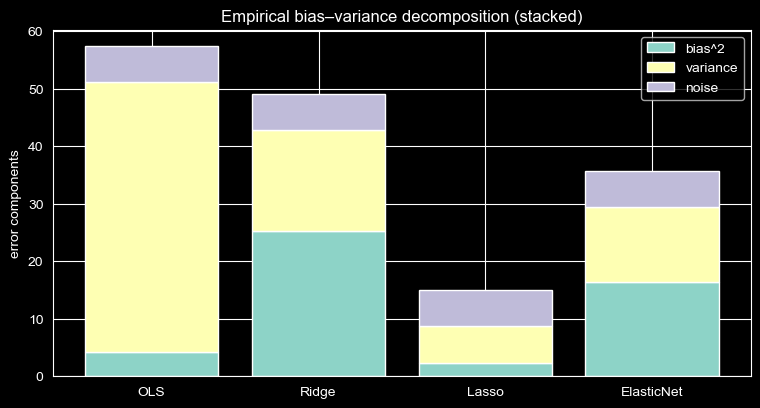

OLS        bias^2=4.254 var=46.891 noise=6.250 total~=57.395
Ridge      bias^2=25.228 var=17.625 noise=6.250 total~=49.103
Lasso      bias^2=2.394 var=6.420 noise=6.250 total~=15.064
ElasticNet bias^2=16.360 var=13.072 noise=6.250 total~=35.681


In [7]:
names = list(bv.keys())
bias2 = [bv[n]["bias2"] for n in names]
var = [bv[n]["var"] for n in names]
noise = [bv[n]["noise"] for n in names]

x = np.arange(len(names))
plt.figure(figsize=(9,4.5))
plt.bar(x, bias2, label="bias^2")
plt.bar(x, var, bottom=bias2, label="variance")
plt.bar(x, noise, bottom=np.array(bias2)+np.array(var), label="noise")
plt.xticks(x, names)
plt.ylabel("error components")
plt.title("Empirical bias–variance decomposition (stacked)")
plt.legend()
plt.show()

for n in names:
    print(f"{n:10s} bias^2={bv[n]['bias2']:.3f} var={bv[n]['var']:.3f} noise={bv[n]['noise']:.3f} total~={bv[n]['mse']:.3f}")


## 8) Stability: sensitivity to data perturbations

Intuition (high-level):
- **Stable** algorithms change little when you perturb the training set.
- Stability is closely related to generalization.
- Regularization (especially strong convex regularization like Ridge) often increases stability.

We'll measure a simple *replace-one* sensitivity:
1. Fit a model on the full dataset.
2. Replace one training point with a fresh sample and refit.
3. Measure change in predictions on a fixed test set.

This isn't a formal stability proof, but it is a useful demonstration.


In [8]:
def stability_experiment(spec: DataSpec, models, T=120, test_n=400):
    X_test = make_correlated_X(test_n, spec.d, corr=spec.corr)
    w_star, _ = make_sparse_w(spec.d, k_nonzero=spec.k_nonzero)

    # base dataset
    X = make_correlated_X(spec.n, spec.d, corr=spec.corr)
    y = X @ w_star + spec.noise_std * np.random.randn(spec.n)

    base_preds = {}
    for name, model in models.items():
        model.fit(X, y)
        base_preds[name] = model.predict(X_test)

    sens = {name: [] for name in models}

    for _ in range(T):
        j = np.random.randint(spec.n)
        X2, y2 = X.copy(), y.copy()
        # replace-one sample
        x_new = make_correlated_X(1, spec.d, corr=spec.corr)
        y_new = float(x_new @ w_star + spec.noise_std * np.random.randn())
        X2[j, :] = x_new
        y2[j] = y_new

        for name, model in models.items():
            model.fit(X2, y2)
            p2 = model.predict(X_test)
            # average absolute change in predictions
            delta = np.mean(np.abs(p2 - base_preds[name]))
            sens[name].append(delta)

    return {name: (np.mean(vals), np.std(vals)) for name, vals in sens.items()}

spec_stab = DataSpec(n=35, d=60, k_nonzero=6, noise_std=3.0, corr=0.75)
models_stab = make_models(alpha_ridge=20.0, alpha_lasso=0.2, alpha_en=0.3, l1_ratio=0.5)
stab = stability_experiment(spec_stab, models_stab, T=150, test_n=700)
stab


/var/folders/fj/gcznyh116bjd9lbw6th5yrpr0000gn/T/ipykernel_46272/1430225084.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_new = float(x_new @ w_star + spec.noise_std * np.random.randn())
/var/folders/fj/gcznyh116bjd9lbw6th5yrpr0000gn/T/ipykernel_46272/1430225084.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_new = float(x_new @ w_star + spec.noise_std * np.random.randn())
/var/folders/fj/gcznyh116bjd9lbw6th5yrpr0000gn/T/ipykernel_46272/1430225084.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before pe

{'OLS': (1.8458097163791785, 0.9992142423154434),
 'Ridge': (0.8156624224139205, 0.41580684693267683),
 'Lasso': (0.9850962665351365, 0.5748768623722279),
 'ElasticNet': (0.9476520313026585, 0.4849901221571524)}

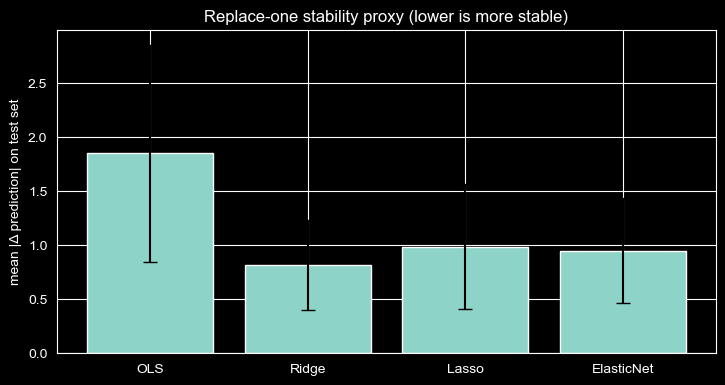

OLS        mean |Δpred| = 1.8458 ± 0.9992
Ridge      mean |Δpred| = 0.8157 ± 0.4158
Lasso      mean |Δpred| = 0.9851 ± 0.5749
ElasticNet mean |Δpred| = 0.9477 ± 0.4850


In [9]:
names = list(stab.keys())
means = [stab[n][0] for n in names]
stds = [stab[n][1] for n in names]

plt.figure(figsize=(8.5,4.2))
x = np.arange(len(names))
plt.bar(x, means, yerr=stds, capsize=5)
plt.xticks(x, names)
plt.ylabel("mean |Δ prediction| on test set")
plt.title("Replace-one stability proxy (lower is more stable)")
plt.show()

for n in names:
    mu, s = stab[n]
    print(f"{n:10s} mean |Δpred| = {mu:.4f} ± {s:.4f}")


## 9) Summary table: assumptions → loss/regularizer

| Assumption | Mathematical form | Leads to (MAP objective) |
|---|---:|---|
| Gaussian noise | $\epsilon\sim\mathcal{N}(0,\sigma^2)$ | squared loss $\sum (y-x^Tw)^2$ |
| Laplace noise | $\epsilon\sim\text{Laplace}(0,b)$ | absolute loss $\sum |y-x^Tw|$ |
| Gaussian prior on $w$ | $w\sim\mathcal{N}(0,\tau^2 I)$ | L2 penalty $\|w\|_2^2$ (Ridge) |
| Laplace prior on $w$ | $p(w_j)\propto e^{-|w_j|/b}$ | L1 penalty $\|w\|_1$ (Lasso) |
| Gaussian + Laplace prior | product / sum in log space | Elastic Net $\lambda_2\|w\|_2^2+\lambda_1\|w\|_1$ |

Key takeaways:
- Regularization is not a hack: it corresponds to a prior.
- Bias–variance: stronger priors generally increase bias but reduce variance.
- Stability tends to improve with regularization (especially strongly convex L2).


## 10) Exercises (for students)

1. **Derivation exercise:** Starting from the Gaussian prior and Gaussian likelihood, derive the Ridge objective and identify how $\alpha$ relates to $(\sigma^2,\tau^2)$.

2. **Sparsity exercise:** Increase `k_nonzero` and decrease the magnitude of the true weights (make them smaller). What happens to Lasso's bias? When does Ridge outperform Lasso?

3. **Correlation exercise:** Change `corr` from 0.0 to 0.9. Observe coefficient paths and stability. Why does correlated design make sparse recovery harder?

4. **Noise model exercise:** Replace the Gaussian noise with occasional large outliers. Which loss (L2 vs L1) would you choose, and why?

5. **Posterior vs MAP:** For Bayesian linear regression with Gaussian prior/likelihood, the posterior is Gaussian. Research and implement the posterior mean predictor. Compare with Ridge/MAP.
